# Sentiment Analysis with LSTM — Giai đoạn 5: So sánh & Tổng hợp kết quả

**Yêu cầu:** đã chạy xong Giai đoạn 1 (data prep), Giai đoạn 2 (baseline) và Giai đoạn 4 (extensions) — có sẵn trong `MyDrive/imdb_sentiment_artifacts/`:
- `baseline_results.json`, `extension_results.json`
- `vocab.pkl`, `imdb_processed.pt`
- Checkpoint: `baseline_lstm_best.pt`, `gru_best.pt`, `bilstm_best.pt`, `glove_lstm_best.pt`

Notebook này **không train lại gì** — chỉ load kết quả/checkpoint đã lưu để tổng hợp báo cáo cuối cùng.

**Nội dung:**
1. Mount Drive + load toàn bộ kết quả đã lưu
2. Bảng so sánh 4 model + biểu đồ
3. Ví dụ dự đoán thực tế (đúng & sai) trên dữ liệu test — dùng model tốt nhất
4. Nhận xét tổng hợp


## 1. Mount Drive + load kết quả đã lưu

In [1]:
from google.colab import drive
drive.mount('/content/drive')
ARTIFACT_DIR = "/content/drive/MyDrive/imdb_sentiment_artifacts"

import json
import pickle
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

with open(f"{ARTIFACT_DIR}/baseline_results.json") as f:
    baseline_results = json.load(f)
with open(f"{ARTIFACT_DIR}/extension_results.json") as f:
    extension_results = json.load(f)

# Gộp baseline vào cùng dict với 3 extension để xử lý chung
all_results = {"Baseline (LSTM)": baseline_results, **extension_results}
print("Đã load kết quả của", list(all_results.keys()))


Mounted at /content/drive
Using device: cuda
Đã load kết quả của ['Baseline (LSTM)', 'GRU', 'BiLSTM', 'GloVe+LSTM']


## 2. Bảng so sánh 4 model + biểu đồ

In [2]:
summary_rows = []
for name, res in all_results.items():
    summary_rows.append({
        "Model": name,
        "Params": res.get("num_params", "-"),
        "Train time (s)": round(res.get("train_time_sec", 0), 1) if "train_time_sec" in res else "-",
        "Test Accuracy": round(res["test_accuracy"], 4),
        "Precision": round(res["test_precision"], 4),
        "Recall": round(res["test_recall"], 4),
        "F1": round(res["test_f1"], 4),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


          Model  Params Train time (s)  Test Accuracy  Precision  Recall     F1
Baseline (LSTM) 2692225              -         0.8439     0.8468  0.8398 0.8433
            GRU 2659201           41.5         0.8643     0.8584  0.8726 0.8654
         BiLSTM 2824449           66.8         0.8350     0.8449  0.8206 0.8326
     GloVe+LSTM 2117889           40.2         0.8553     0.8820  0.8204 0.8501


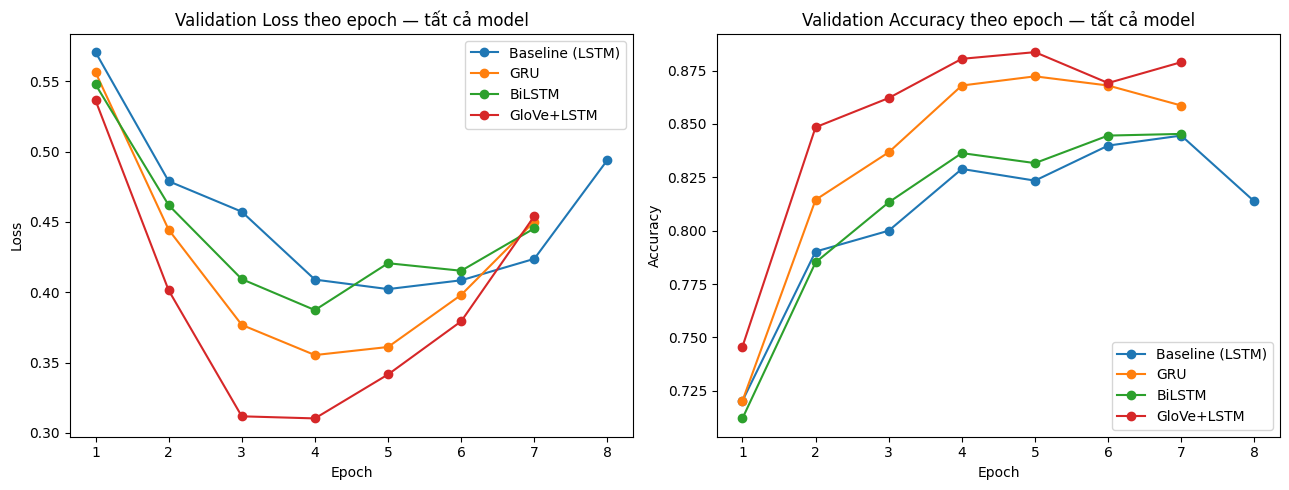

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, res in all_results.items():
    if "history" in res:
        epochs_range = range(1, len(res["history"]["val_loss"]) + 1)
        axes[0].plot(epochs_range, res["history"]["val_loss"], marker="o", label=name)
        axes[1].plot(epochs_range, res["history"]["val_acc"], marker="o", label=name)

axes[0].set_title("Validation Loss theo epoch — tất cả model")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[1].set_title("Validation Accuracy theo epoch — tất cả model")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()


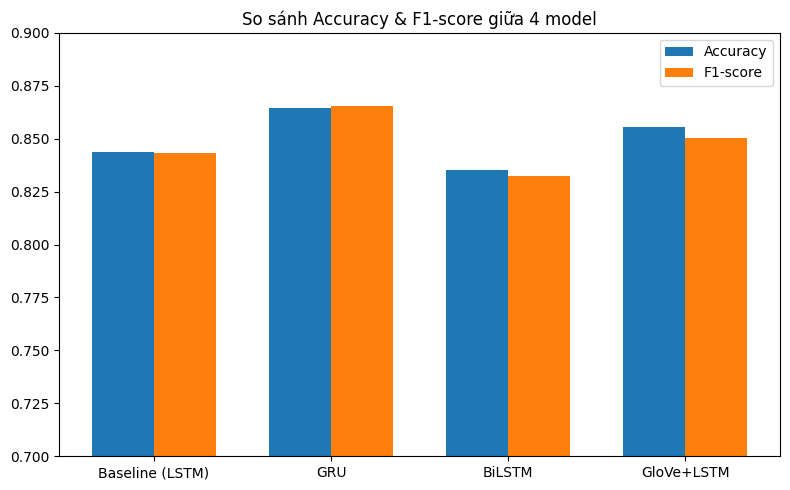

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(summary_df))
width = 0.35
ax.bar(x - width/2, summary_df["Test Accuracy"], width, label="Accuracy")
ax.bar(x + width/2, summary_df["F1"], width, label="F1-score")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Model"])
ax.set_ylim(0.7, 0.9)
ax.set_title("So sánh Accuracy & F1-score giữa 4 model")
ax.legend()
plt.tight_layout(); plt.show()


## 3. Ví dụ dự đoán thực tế (đúng & sai)

Load lại vocab + test data + checkpoint model tốt nhất (GloVe+LSTM) để chạy dự đoán thật trên vài mẫu — minh chứng model hoạt động thật, không chỉ là con số thống kê.

In [5]:
from torch.utils.data import TensorDataset, DataLoader

with open(f"{ARTIFACT_DIR}/vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

data = torch.load(f"{ARTIFACT_DIR}/imdb_processed.pt")
X_test, y_test = data["X_test"], data["y_test"]
VOCAB_SIZE = len(vocab)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

idx_to_word = {v: k for k, v in vocab.items()}

def decode_sequence(seq_tensor, max_words=60):
    words = [idx_to_word.get(idx.item(), "<unk>") for idx in seq_tensor if idx.item() != 0]
    return " ".join(words[:max_words]) + ("..." if len(words) > max_words else "")

print("Đã load test set:", X_test.shape)


Đã load test set: torch.Size([25000, 250])


In [6]:
# Load lại kiến trúc GloVe+LSTM (model tốt nhất) và checkpoint đã lưu
class GloVeLSTMSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.pad_idx = pad_idx

    def forward(self, x):
        lengths = (x != self.pad_idx).sum(dim=1).cpu()
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths, batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        hidden = hidden.squeeze(0)
        return self.fc(self.dropout(hidden)).squeeze(1)

best_model = GloVeLSTMSentimentModel(vocab_size=VOCAB_SIZE).to(device)
best_model.load_state_dict(torch.load(f"{ARTIFACT_DIR}/glove_lstm_best.pt", map_location=device))
best_model.eval()
print("Đã load checkpoint glove_lstm_best.pt")


Đã load checkpoint glove_lstm_best.pt


In [7]:
def show_predictions(model, model_name, n_correct=3, n_wrong=3):
    model.eval()
    label_map = {0: "negative", 1: "positive"}
    correct_examples, wrong_examples = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb_gpu = xb.to(device)
            probs = torch.sigmoid(model(xb_gpu)).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            for i in range(len(yb)):
                true_label = int(yb[i].item())
                pred_label = int(preds[i])
                entry = (xb[i], true_label, pred_label, probs[i])
                if pred_label == true_label and len(correct_examples) < n_correct:
                    correct_examples.append(entry)
                elif pred_label != true_label and len(wrong_examples) < n_wrong:
                    wrong_examples.append(entry)
            if len(correct_examples) >= n_correct and len(wrong_examples) >= n_wrong:
                break

    print(f"\n{'='*70}\n{model_name} — Ví dụ DỰ ĐOÁN ĐÚNG\n{'='*70}")
    for seq, true_l, pred_l, prob in correct_examples:
        print(f"\nText: {decode_sequence(seq)}")
        print(f"→ Actual: {label_map[true_l]} | Predicted: {label_map[pred_l]} (prob={prob:.3f})")

    print(f"\n{'='*70}\n{model_name} — Ví dụ DỰ ĐOÁN SAI\n{'='*70}")
    for seq, true_l, pred_l, prob in wrong_examples:
        print(f"\nText: {decode_sequence(seq)}")
        print(f"→ Actual: {label_map[true_l]} | Predicted: {label_map[pred_l]} (prob={prob:.3f})")

show_predictions(best_model, "GloVe+LSTM (best model)")



GloVe+LSTM (best model) — Ví dụ DỰ ĐOÁN ĐÚNG

Text: i love sci fi and am willing to put up with a lot sci fi movies tv are usually <unk> under appreciated and misunderstood i tried to like this i really did but it is to good tv sci fi as babylon 5 is to star trek the original silly prosthetics cheap cardboard sets stilted dialogues cg that doesn't match...
→ Actual: negative | Predicted: negative (prob=0.005)

Text: worth the entertainment value of a rental especially if you like action movies this one features the usual car chases fights with the great van damme kick style shooting battles with the 40 shell load shotgun and even terrorist style bombs all of this is entertaining and competently handled but there is nothing that really blows you away if you've...
→ Actual: negative | Predicted: negative (prob=0.002)

Text: its a totally average film with a few semi alright action sequences that make the plot seem a little better and remind the viewer of the classic van dam films parts 

## 4. Nhận xét tổng hợp

- **GloVe+LSTM tốt nhất** — accuracy và F1 cao nhất, số tham số ít nhất và train nhanh nhất nhờ tận dụng pre-trained embedding thay vì học từ đầu.
- **GRU gần như ngang GloVe** — kiến trúc đơn giản hơn LSTM (ít cổng hơn) nhưng hiệu quả tương đương.
- **Bidirectional LSTM thấp hơn kỳ vọng** — Precision cao nhưng Recall thấp, cho thấy model thiên lệch dự đoán về một lớp; nhiều khả năng do số tham số tầng cuối gấp đôi khiến cần tune riêng (learning rate/dropout) thay vì dùng chung cấu hình với các model khác trong phạm vi 5 epoch.
- **Bài học chung:** kiến trúc phức tạp hơn (BiLSTM) không tự động đảm bảo kết quả tốt hơn nếu không được tối ưu riêng — hiệu quả thực tế phụ thuộc vào cả kiến trúc lẫn cách huấn luyện.

**Dữ liệu này sẵn sàng để đưa vào README/slide tổng kết (Giai đoạn 6).**
